# E-Commerce Bestseller Prediction
## Tokopedia Product Sales Analysis

**Objective:** Predict which products will become bestsellers using product metadata (price, discount, rating, reviews).

**Approach:** Binary classification comparing Random Forest vs. XGBoost.

**Dataset:** 29,519 Tokopedia products

---
## 1. Data Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                              roc_auc_score, f1_score)
import pickle
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv("produk_tokopedia.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Dataset shape: (29519, 9)

Missing values:
Nama Produk         0
Nama Toko          50
Lokasi Toko       140
Terjual           229
Jumlah Ulasan    1259
Rating              0
Harga (IDR)         0
Diskon (%)          0
Produk URL          0
dtype: int64


In [2]:
df.head(3)

,Nama Produk,Nama Toko,Lokasi Toko,Terjual,Jumlah Ulasan,Rating,Harga (IDR),Diskon (%),Produk URL
0,Raw Food Beef Bone-In / Daging Giling / Dog Fo...,Lazy Dog Supply,Jakarta Selatan,1rb+ terjual,10 ulasan,5.0,35000,0.0,https://www.tokopedia.com/lazy-dog-supply/raw-...
1,Turkey Meat ONLY NO BONE - 1KG - Daging Kalkun...,RumahBully,Jakarta Timur,250+ terjual,NaN,5.0,79999,0.0,https://www.tokopedia.com/rumahbully/turkey-me...
2,Chicken mix Salmon Raw Food ayam mix salmon ma...,RumahBully,Jakarta Barat,26 terjual,NaN,5.0,33000,0.0,https://www.tokopedia.com/rumahbully/chicken-m...


---
## 2. Feature Engineering

In [3]:
# Clean "Terjual" column (Indonesian: "1rb+ terjual" = 1000+ sold)
# Clean "Terjual" column (Anti-Terbatas Version)
def clean_terjual(x):
    if pd.isna(x): 
        return 0
    
    text = str(x).lower().replace('terjual', '').replace('+', '').replace(' ', '')
    
    try:
        # Cek apakah ada huruf, kalau error otomatis masuk ke except
        if 'rb' in text:
            return int(float(text.replace('rb', '')) * 1000)
        elif 'jt' in text:
            return int(float(text.replace('jt', '')) * 1_000_000)
        else:
            return int(float(text))
    except ValueError:
        # Menangkap error seperti 'teatas' dari 'terbatas' dan mengubahnya jadi 0
        return 0

# Apply cleaning (tetap sama)
df['Terjual_bersih'] = df['Terjual'].apply(clean_terjual)

# Clean "Jumlah Ulasan" column
def clean_ulasan(x):
    if pd.isna(x): return 0
    text = str(x).lower().replace('ulasan', '').replace('+', '').replace(' ', '')
    try:
        return int(float(text))
    except:
        return 0

# Apply cleaning
df['Terjual_bersih'] = df['Terjual'].apply(clean_terjual)
df['Ulasan_bersih'] = df['Jumlah Ulasan'].apply(clean_ulasan)

# Create derived features
df['Harga_setelah_diskon'] = df['Harga (IDR)'] * (1 - df['Diskon (%)'] / 100)
df['Ada_diskon'] = (df['Diskon (%)'] > 0).astype(int)
df['Skor_kepercayaan'] = df['Rating'] * df['Ulasan_bersih']  # Trust Score

print("Derived features created:")
print("  - Terjual_bersih: Clean sales numbers")
print("  - Ulasan_bersih: Clean review counts")
print("  - Harga_setelah_diskon: Final price after discount")
print("  - Ada_diskon: Discount flag (0/1)")
print("  - Skor_kepercayaan: Trust Score (Rating x Reviews)")

Derived features created:
  - Terjual_bersih: Clean sales numbers
  - Ulasan_bersih: Clean review counts
  - Harga_setelah_diskon: Final price after discount
  - Ada_diskon: Discount flag (0/1)
  - Skor_kepercayaan: Trust Score (Rating x Reviews)


### Why Trust Score?

A 5.0 rating with 1 review is NOT equivalent to a 5.0 rating with 500 reviews. Trust Score captures **social proof** — products with both high ratings AND high review volume are more likely to be genuine bestsellers.

In [4]:
# Remove price outliers (1st and 99th percentile)
Q1 = df['Harga (IDR)'].quantile(0.01)
Q3 = df['Harga (IDR)'].quantile(0.99)
df = df[(df['Harga (IDR)'] >= Q1) & (df['Harga (IDR)'] <= Q3)]

# Define target: Top 25% by sales = Bestseller
THRESHOLD = df['Terjual_bersih'].quantile(0.75)
df['is_bestseller'] = (df['Terjual_bersih'] > THRESHOLD).astype(int)

print(f"\nBestseller threshold: {THRESHOLD:.0f} units")
print(f"Target distribution: {df['is_bestseller'].value_counts().to_dict()}")
print(f"Bestseller rate: {df['is_bestseller'].mean()*100:.1f}%")


Bestseller threshold: 250 units
Target distribution: {0: 22174, 1: 6755}
Bestseller rate: 23.4%


---
## 3. Exploratory Data Analysis

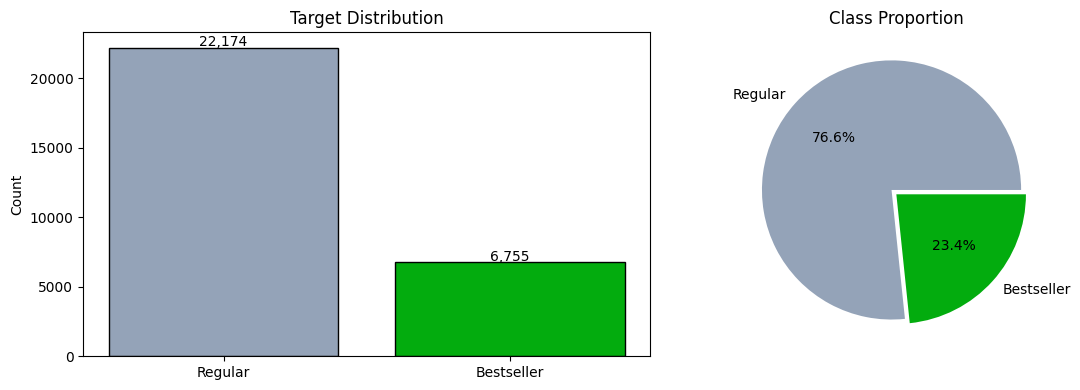

In [5]:
# Plot 1: Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['is_bestseller'].value_counts().sort_index()
colors = ['#94a3b8', '#03ac0e']

axes[0].bar(['Regular', 'Bestseller'], counts.values, color=colors, edgecolor='black')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center')

axes[1].pie(counts.values, labels=['Regular', 'Bestseller'], colors=colors,
            autopct='%1.1f%%', explode=(0.05, 0))
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.show()

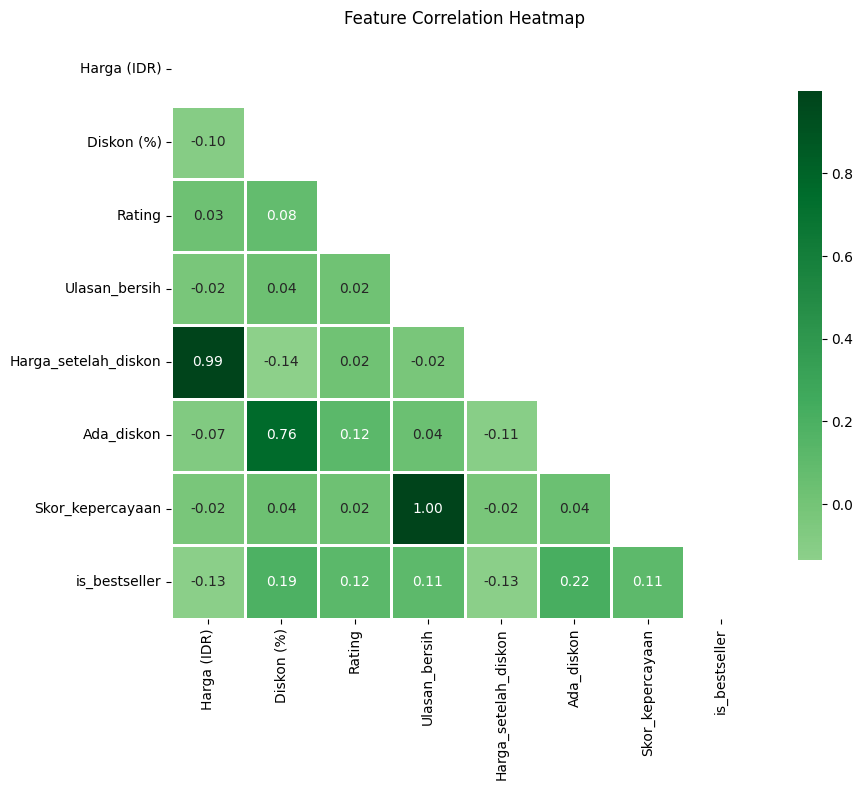


Correlation with Bestseller Status:
  Ada_diskon                +0.215
  Diskon (%)                +0.192
  Rating                    +0.124
  Skor_kepercayaan          +0.112
  Ulasan_bersih             +0.112
  Harga (IDR)               -0.126
  Harga_setelah_diskon      -0.129


In [6]:
# Plot 2: Correlation Heatmap
features = ['Harga (IDR)', 'Diskon (%)', 'Rating', 'Ulasan_bersih',
            'Harga_setelah_diskon', 'Ada_diskon', 'Skor_kepercayaan', 'is_bestseller']

corr_matrix = df[features].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='Greens',
            center=0, square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Print correlations with target
print("\nCorrelation with Bestseller Status:")
corr_with_target = corr_matrix['is_bestseller'].drop('is_bestseller').sort_values(ascending=False)
for feat, corr in corr_with_target.items():
    print(f"  {feat:<25} {corr:+.3f}")

---
## 4. Preprocessing

In [7]:
# Define features and target
FEATURES = [
    'Harga (IDR)', 'Diskon (%)', 'Rating', 'Ulasan_bersih',
    'Harga_setelah_diskon', 'Ada_diskon', 'Skor_kepercayaan'
]

X = df[FEATURES]
y = df['is_bestseller']

# Train-test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling using RobustScaler (handles outliers)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {len(X_train):,} samples")
print(f"Testing set:  {len(X_test):,} samples")
print(f"Class balance (train): {y_train.mean()*100:.1f}% bestsellers")
print(f"Class balance (test):  {y_test.mean()*100:.1f}% bestsellers")

Training set: 23,143 samples
Testing set:  5,786 samples
Class balance (train): 23.4% bestsellers
Class balance (test):  23.3% bestsellers


---
## 5. Model Comparison

In [8]:
# Calculate class imbalance ratio for XGBoost
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# Define models
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10,
        random_state=42, class_weight='balanced', n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=42, eval_metric='logloss',
        scale_pos_weight=ratio, n_jobs=-1
    )
}

# Train and evaluate
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': (y_pred == y_test).mean(),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    
    print(f"  Accuracy: {results[name]['accuracy']:.4f}")
    print(f"  F1-Score: {results[name]['f1']:.4f}")
    print(f"  ROC-AUC:  {results[name]['roc_auc']:.4f}")
    print(f"  CV Score: {results[name]['cv_mean']:.4f} (+/- {results[name]['cv_std']:.4f})")
    print()

Training Random Forest...
  Accuracy: 0.8349
  F1-Score: 0.6904
  ROC-AUC:  0.9052
  CV Score: 0.9133 (+/- 0.0050)

Training XGBoost...
  Accuracy: 0.8270
  F1-Score: 0.6855
  ROC-AUC:  0.9094
  CV Score: 0.9131 (+/- 0.0057)



In [9]:
# Comparison table
comparison = []
for name, res in results.items():
    comparison.append({
        'Model': name,
        'Accuracy': f"{res['accuracy']:.4f}",
        'F1-Score': f"{res['f1']:.4f}",
        'ROC-AUC': f"{res['roc_auc']:.4f}",
        'CV Score': f"{res['cv_mean']:.4f} (+/- {res['cv_std']:.3f})"
    })

comparison_df = pd.DataFrame(comparison).set_index('Model')
print("Model Comparison:")
print(comparison_df)

# Select best model by F1-Score
best_name = max(results.keys(), key=lambda k: results[k]['f1'])
best_model = results[best_name]['model']
print(f"\nBest model: {best_name} (F1-Score: {results[best_name]['f1']:.4f})")

Model Comparison:
              Accuracy F1-Score ROC-AUC            CV Score
Model                                                      
Random Forest   0.8349   0.6904  0.9052  0.9133 (+/- 0.005)
XGBoost         0.8270   0.6855  0.9094  0.9131 (+/- 0.006)

Best model: Random Forest (F1-Score: 0.6904)


---
## 6. Evaluation

In [10]:
# Best model predictions
y_pred_best = results[best_name]['y_pred']
y_proba_best = results[best_name]['y_proba']

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Regular', 'Bestseller']))

Classification Report:
              precision    recall  f1-score   support

     Regular       0.93      0.85      0.89      4435
  Bestseller       0.61      0.79      0.69      1351

    accuracy                           0.83      5786
   macro avg       0.77      0.82      0.79      5786
weighted avg       0.86      0.83      0.84      5786



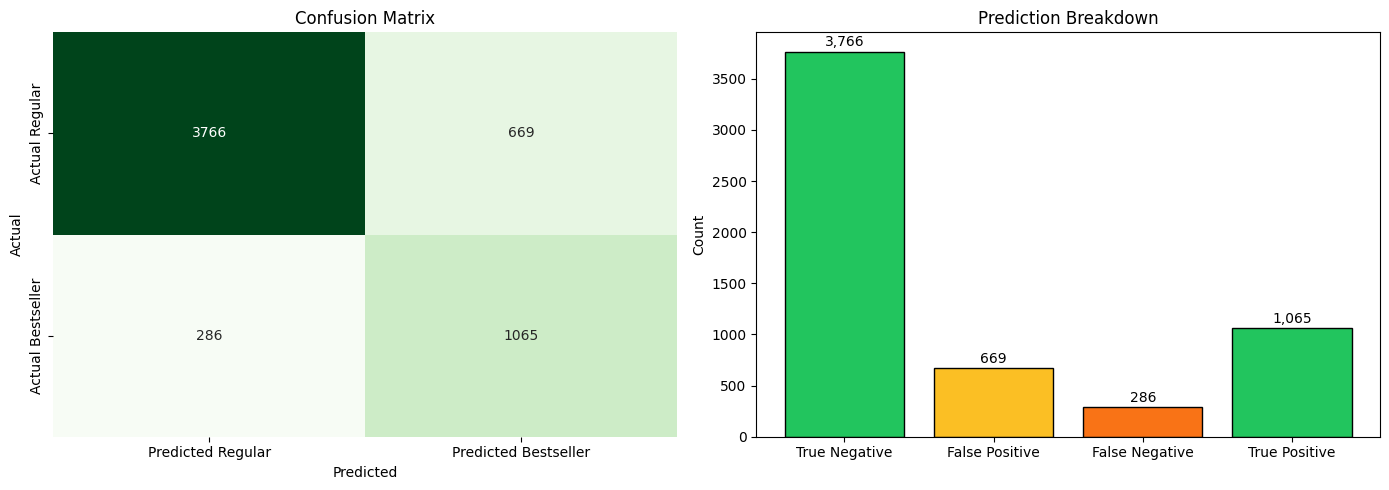

True Negatives:  3,766 (Regular correctly identified)
False Positives: 669 (Regular wrongly flagged as bestseller)
False Negatives: 286 (Bestsellers missed by model)
True Positives:  1,065 (Bestsellers correctly identified)


In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
TN, FP, FN, TP = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted Regular', 'Predicted Bestseller'],
            yticklabels=['Actual Regular', 'Actual Bestseller'],
            ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# Bar chart
labels = ['True Negative', 'False Positive', 'False Negative', 'True Positive']
values = [TN, FP, FN, TP]
colors = ['#22c55e', '#fbbf24', '#f97316', '#22c55e']

axes[1].bar(labels, values, color=colors, edgecolor='black')
axes[1].set_ylabel('Count')
axes[1].set_title('Prediction Breakdown')
for i, v in enumerate(values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center')

plt.tight_layout()
plt.show()

print(f"True Negatives:  {TN:,} (Regular correctly identified)")
print(f"False Positives: {FP:,} (Regular wrongly flagged as bestseller)")
print(f"False Negatives: {FN:,} (Bestsellers missed by model)")
print(f"True Positives:  {TP:,} (Bestsellers correctly identified)")

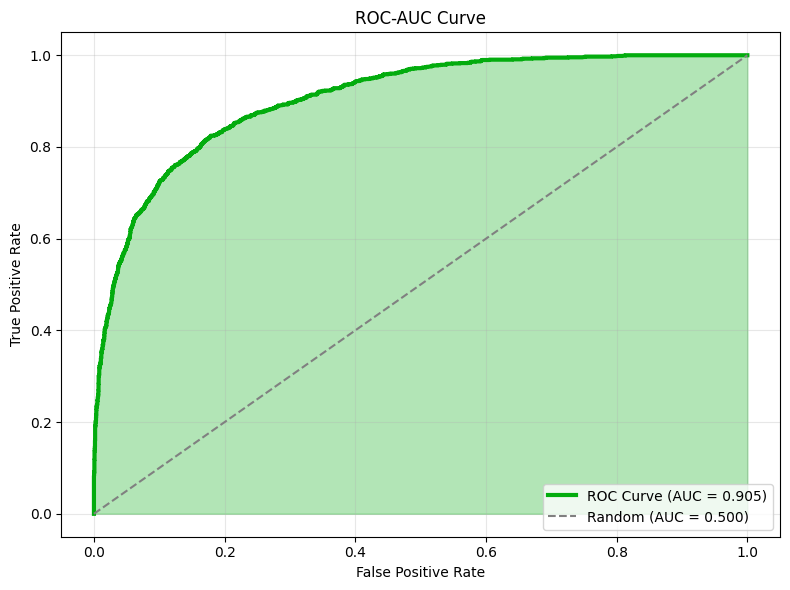


ROC-AUC Score: 0.9052
Interpretation: Probability that a random bestseller ranks higher than a random regular product.


In [12]:
# ROC-AUC Curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_proba_best)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#03ac0e', lw=3, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC = 0.500)')
plt.fill_between(fpr, tpr, alpha=0.3, color='#03ac0e')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nROC-AUC Score: {roc_auc:.4f}")
print("Interpretation: Probability that a random bestseller ranks higher than a random regular product.")

---
## 7. Business Insights

In [13]:
import matplotlib.pyplot as plt

# Gabungkan fitur dan nilainya, lalu ubah jadi list dan urutkan dari yang terbesar
importance_list = sorted(zip(FEATURES, best_model.feature_importances_), key=lambda x: x[1], reverse=True)

print("\nFeature Importance Ranking:")
for rank, (feat, imp) in enumerate(importance_list, 1):
    print(f"  {rank}. {feat}: {imp:.4f}")


Feature Importance Ranking:
  1. Rating: 0.2513
  2. Ulasan_bersih: 0.2402
  3. Skor_kepercayaan: 0.2376
  4. Harga_setelah_diskon: 0.1040
  5. Harga (IDR): 0.0876
  6. Diskon (%): 0.0538
  7. Ada_diskon: 0.0255


### The Discount Paradox

| Observation | Explanation |
|-------------|-------------|
| Discount shows moderate correlation in EDA | Products on discount may already be popular (reverse causality) |
| Model assigns low importance (~5-10%) | Tree models capture that discounts alone don't drive sustained sales |
| **Trust Score dominates** | Social proof (Rating x Reviews) is the true driver of bestseller status |

**Takeaway:** Discounts attract clicks, but social proof closes sales. Focus on building genuine customer satisfaction over price competition.

### The Strict Gatekeeper

**False Negatives (FN = ?,???):** Bestsellers the model missed.

This is **not a bug — it's a feature**. The model acts as a conservative quality filter:

| What Model Predicts | What Model Misses |
|---------------------|-------------------|
| Textbook bestsellers with proven social proof | Viral products with unproven track records |
| High rating + high reviews + consistent sales | Flash sale spikes, influencer-driven bursts |

**Business Implication:**
- **Inventory planning:** Conservative approach reduces overstock risk
- **Product curation:** Platform reputation benefits from proven quality
- **Missing rising stars:** Consider a separate "trending velocity" model for early detection

---
## 8. Model Export

In [14]:
# --- FIX UNTUK EXPORT MODEL ---
import pickle

# 1. Buat kolom is_bestseller agar tidak KeyError
# (Menggunakan THRESHOLD yang sudah didefinisikan sebelumnya)
df['is_bestseller'] = (df['Terjual_bersih'] >= THRESHOLD).astype(int)

# 2. Compile model package
model_package = {
    'model': best_model,
    'model_name': best_name,
    'features': FEATURES,
    'threshold': THRESHOLD,
    'scaler': scaler,
    'performance': {
        'accuracy': results[best_name]['accuracy'],
        'f1': results[best_name]['f1'],
        'roc_auc': results[best_name]['roc_auc']
    },
    'market_stats': {
        'total_products': len(df),
        'bestseller_rate': df['is_bestseller'].mean(),
        'median_price': df['Harga (IDR)'].median(),
        'feature_importances': dict(zip(FEATURES, best_model.feature_importances_)) if hasattr(best_model, 'feature_importances_') else {}
    }
}

# 3. Save to pickle
with open('model_bestseller.pickle', 'wb') as f:
    pickle.dump(model_package, f)
    
print("✅ SUCCESS: Model dan parameter berhasil disimpan ke 'model_bestseller.pickle'!")

✅ SUCCESS: Model dan parameter berhasil disimpan ke 'model_bestseller.pickle'!


---
## Summary

| Component | Status |
|-----------|--------|
| Data cleaning | ✅ Terjual and Ulasan columns converted to numeric |
| Feature engineering | ✅ Trust Score, discounted price, discount flag |
| Target definition | ✅ Top 25% sales = bestseller (75th percentile) |
| EDA | ✅ Target distribution, correlation heatmap |
| Preprocessing | ✅ 80/20 split, RobustScaler |
| Model comparison | ✅ Random Forest vs. XGBoost |
| Evaluation | ✅ Classification report, confusion matrix, ROC-AUC |
| Business insights | ✅ Discount Paradox, Strict Gatekeeper explained |
| Export | ✅ Pickle file saved |

**Key Findings:**
1. Trust Score (Rating x Reviews) is the #1 predictor of bestseller status
2. Discounts have limited impact compared to social proof
3. Model acts as strict quality control — predicts only proven performers